In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

c:\Users\Acer3\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Acer3\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## Descrição do conjunto de dados

Neste notebook, utilizaremos um conjunto de dados disponibilizado no desafio de *machine learning* promovido pela **SEG (Society of Exploration Geophysicists)** em 2016. O desafio pode ser encontrado no repositório oficial: <a href="https://github.com/seg/2016-ml-contest">SEG 2016 Machine Learning Contest</a>.

O objetivo do problema é realizar a **classificação de fácies litológicas** a partir de dados de perfis de poço. Em outras palavras, queremos treinar modelos de aprendizado de máquina capazes de reconhecer diferentes tipos de rochas ou associações litológicas com base em atributos medidos ao longo do poço.

A variável alvo do problema é a coluna **`Facies`**, que representa a classe litológica de cada amostra. Neste conjunto de dados, as fácies foram divididas em **9 classes**:

1. **Nonmarine sandstone**
2. **Nonmarine coarse siltstone**
3. **Nonmarine fine siltstone**
4. **Marine siltstone and shale**
5. **Mudstone (limestone)**
6. **Wackestone (limestone)**
7. **Dolomite**
8. **Packstone-grainstone (limestone)**
9. **Phylloid-algal bafflestone (limestone)**

Essas classes também possuem siglas, que facilitam a interpretação e a visualização dos resultados:

| Label | Sigla | Fácies adjacentes | Descrição |
|:----:|:-----:|:-----------------:|-----------|
| 1 | SS   | 2 | Nonmarine sandstone |
| 2 | CSiS | 1, 3 | Nonmarine coarse siltstone |
| 3 | FSiS | 2 | Nonmarine fine siltstone |
| 4 | SiSh | 5 | Marine siltstone and shale |
| 5 | MS   | 4, 6 | Mudstone (limestone) |
| 6 | WS   | 5, 7 | Wackestone (limestone) |
| 7 | D    | 6, 8 | Dolomite |
| 8 | PS   | 6, 7, 9 | Packstone-grainstone (limestone) |
| 9 | BS   | 7, 8 | Phylloid-algal bafflestone (limestone) |

### O que significa "fácies adjacentes"?

A coluna **fácies adjacentes** indica classes que são geologicamente próximas ou que podem ser mais facilmente confundidas entre si. Isso é importante porque, em muitos problemas reais de geologia e geofísica, a transição entre litologias não ocorre de forma abrupta. Em vez disso, pode haver mudanças graduais nas propriedades das rochas, tornando a classificação mais desafiadora.

Ao longo desta aula, utilizaremos esse dataset para explorar técnicas de aprendizado de máquina voltadas à **classificação de fácies**, discutindo tanto os aspectos computacionais quanto a interpretação geofísica dos resultados.

In [2]:
# Funções
def plot_well_logs(
    df,
    well_name,
    cols,
    depth_col='Depth',
    well_col='Well Name',
    depth_unit='m',
    x_units=None,
    figsize=(10, 12),
    title=None,
    sharey=True
):
    """
    Plota curvas de perfis para um poço específico.

    Parâmetros
    ----------
    df : pandas.DataFrame
        DataFrame contendo os dados dos perfis.
    well_name : str
        Nome do poço a ser plotado.
    cols : list of str
        Lista com os nomes das colunas a serem exibidas.
    depth_col : str, default='Depth'
        Nome da coluna de profundidade.
    well_col : str, default='Well Name'
        Nome da coluna que identifica o poço.
    depth_unit : str, default='m'
        Unidade da profundidade.
    x_units : dict or None, default=None
        Dicionário com as unidades de cada curva.
        Exemplo: {'GR': 'API', 'PHIND': 'v/v'}
    figsize : tuple, default=(10, 12)
        Tamanho da figura.
    title : str or None, default=None
        Título geral da figura.
    sharey : bool, default=True
        Se True, compartilha o eixo y entre os subplots.

    Retorna
    -------
    fig, axes
        Objetos da figura e dos eixos.
    """
    df_well = df[df[well_col] == well_name]

    fig, axes = plt.subplots(
        ncols=len(cols),
        figsize=figsize,
        sharey=sharey
    )

    if len(cols) == 1:
        axes = [axes]

    if x_units is None:
        x_units = {}

    for col, ax in zip(cols, axes):
        ax.plot(df_well[col], df_well[depth_col])
        ax.invert_yaxis()
        ax.grid(True)

        ax.set_title(col)

        unit = x_units.get(col, '')
        ax.set_xlabel(unit)

    axes[0].set_ylabel(f'{depth_col} ({depth_unit})')

    if title is None:
        title = f'Poço: {well_name}'

    fig.suptitle(title, fontsize=16, y=1.02)
    fig.tight_layout()

    return fig, axes

##### Carregando o dataset

In [3]:
# Carregando o dataset facies_vector.csv
df = pd.read_csv('..\\..\\data\\csv\\facies_vectors.csv')

# Verificando os tipos de variáveis e a presença de valores nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4149 entries, 0 to 4148
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Facies     4149 non-null   int64  
 1   Formation  4149 non-null   str    
 2   Well Name  4149 non-null   str    
 3   Depth      4149 non-null   float64
 4   GR         4149 non-null   float64
 5   ILD_log10  4149 non-null   float64
 6   DeltaPHI   4149 non-null   float64
 7   PHIND      4149 non-null   float64
 8   PE         3232 non-null   float64
 9   NM_M       4149 non-null   int64  
 10  RELPOS     4149 non-null   float64
dtypes: float64(7), int64(2), str(2)
memory usage: 413.0 KB


In [4]:
#Criando uma coluna com os labels (caracteres) das facies
def litologia(facies):
    if facies == 1: return 'Nonmarine sandstone'
    if facies == 2: return 'Nonmarine coarse siltstone'
    if facies == 3: return 'Nonmarine fine siltstone'
    if facies == 4: return 'Marine siltstone and shale'
    if facies == 5: return 'Mudstone (limestone)'
    if facies == 6: return 'Wackestone (limestone)'
    if facies == 7: return 'Dolomite'
    if facies == 8: return 'Packstone-grainstone (limestone)'
    if facies == 9:
        return 'Phylloid-algal bafflestone (limestone)'
    

df['Labels_char'] = df.Facies.apply(litologia)
df.head()

,Facies,Formation,Well Name,Depth,GR,ILD_log10,DeltaPHI,PHIND,PE,NM_M,RELPOS,Labels_char
0,3,A1 SH,SHRIMPLIN,2793.0,77.45,0.664,9.9,11.915,4.6,1,1.000,Nonmarine fine siltstone
1,3,A1 SH,SHRIMPLIN,2793.5,78.26,0.661,14.2,12.565,4.1,1,0.979,Nonmarine fine siltstone
2,3,A1 SH,SHRIMPLIN,2794.0,79.05,0.658,14.8,13.050,3.6,1,0.957,Nonmarine fine siltstone
3,3,A1 SH,SHRIMPLIN,2794.5,86.10,0.655,13.9,13.115,3.5,1,0.936,Nonmarine fine siltstone
4,3,A1 SH,SHRIMPLIN,2795.0,74.58,0.647,13.5,13.300,3.4,1,0.915,Nonmarine fine siltstone


(<Figure size 1000x1200 with 5 Axes>,
 array([<Axes: title={'center': 'GR'}, xlabel='API', ylabel='Depth (m)'>,
        <Axes: title={'center': 'ILD_log10'}, xlabel='log10(ohm.m)'>,
        <Axes: title={'center': 'DeltaPHI'}, xlabel='v/v'>,
        <Axes: title={'center': 'PHIND'}, xlabel='v/v'>,
        <Axes: title={'center': 'PE'}, xlabel='b/e'>], dtype=object))

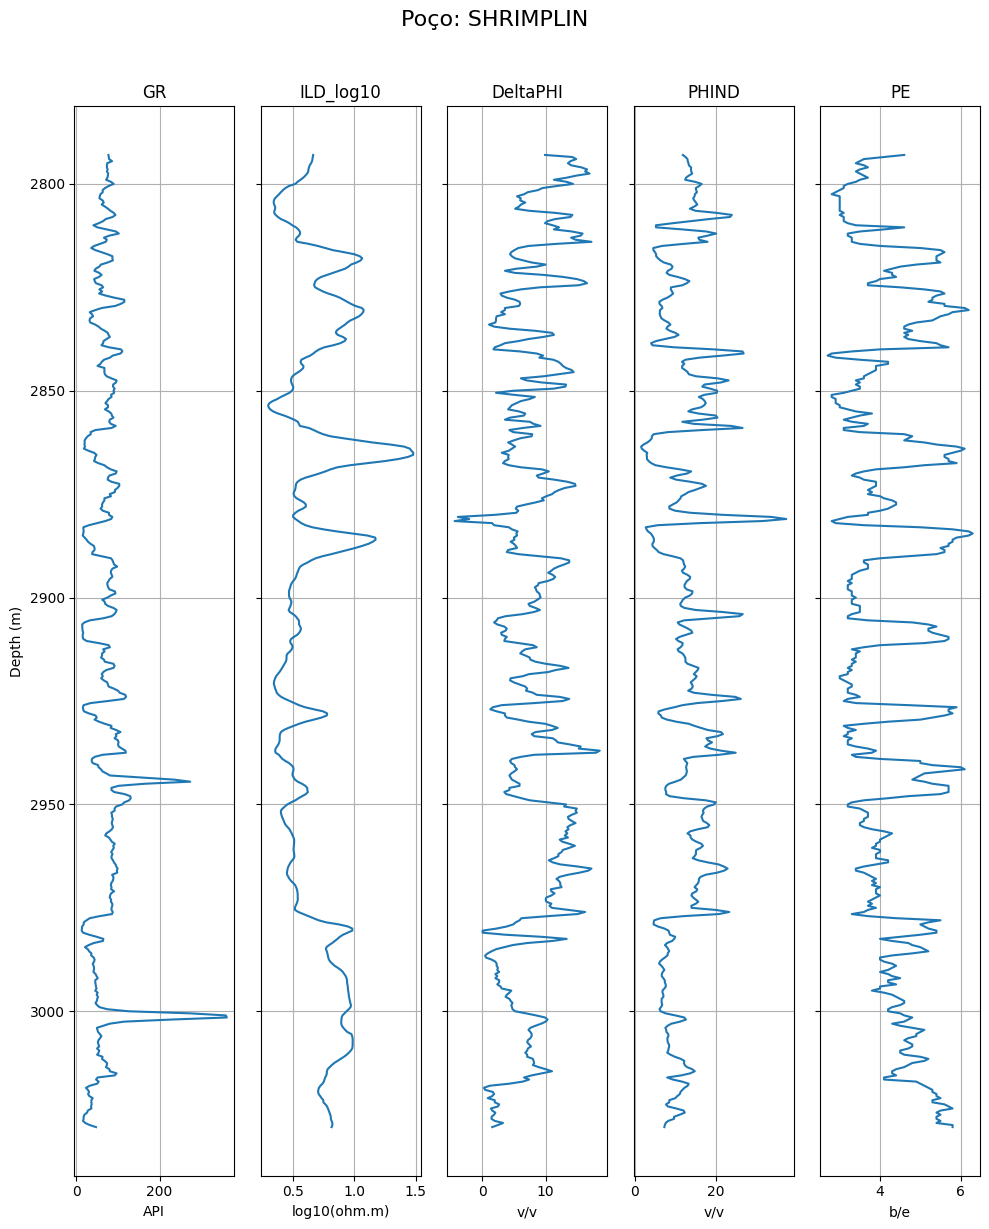

In [5]:
cols = ['GR', 'ILD_log10', 'DeltaPHI', 'PHIND', 'PE']

units = {
    'GR': 'API',
    'ILD_log10': 'log10(ohm.m)',
    'DeltaPHI': 'v/v',
    'PHIND': 'v/v',
    'PE': 'b/e'
}

plot_well_logs(
    df=df,
    well_name='SHRIMPLIN',
    cols=cols,
    depth_unit='m',
    x_units=units
)

In [6]:
# Verificando quais poços tem medidas ausentes
df.isna().groupby(df['Well Name']).sum()

,Facies,Formation,Well Name,Depth,GR,ILD_log10,DeltaPHI,PHIND,PE,NM_M,RELPOS,Labels_char
Well Name,,,,,,,,,,,,
ALEXANDER D,0,0,0,0,0,0,0,0,466,0,0,0
CHURCHMAN BIBLE,0,0,0,0,0,0,0,0,0,0,0,0
CROSS H CATTLE,0,0,0,0,0,0,0,0,0,0,0,0
KIMZEY A,0,0,0,0,0,0,0,0,439,0,0,0
LUKE G U,0,0,0,0,0,0,0,0,0,0,0,0
NEWBY,0,0,0,0,0,0,0,0,0,0,0,0
NOLAN,0,0,0,0,0,0,0,0,0,0,0,0
Recruit F9,0,0,0,0,0,0,0,0,12,0,0,0
SHANKLE,0,0,0,0,0,0,0,0,0,0,0,0


In [7]:
# Plotando o número de ocorrências de cada litologia
df.groupby(['Well Name', 'Labels_char']).size().unstack(fill_value=0)

Labels_char,Dolomite,Marine siltstone and shale,Mudstone (limestone),Nonmarine coarse siltstone,Nonmarine fine siltstone,Nonmarine sandstone,Packstone-grainstone (limestone),Phylloid-algal bafflestone (limestone),Wackestone (limestone)
Well Name,,,,,,,,,
ALEXANDER D,16,44,26,117,91,0,98,5,69
CHURCHMAN BIBLE,34,13,30,56,51,8,75,50,87
CROSS H CATTLE,2,25,28,142,47,158,68,0,31
KIMZEY A,27,43,53,85,74,9,90,7,51
LUKE G U,20,35,2,117,129,0,74,0,84
NEWBY,16,58,28,98,80,0,56,31,96
NOLAN,4,28,47,118,68,4,116,0,30
Recruit F9,0,0,0,0,0,0,0,80,0
SHANKLE,17,7,19,89,117,89,40,0,71


<Axes: xlabel='count', ylabel='Labels_char'>

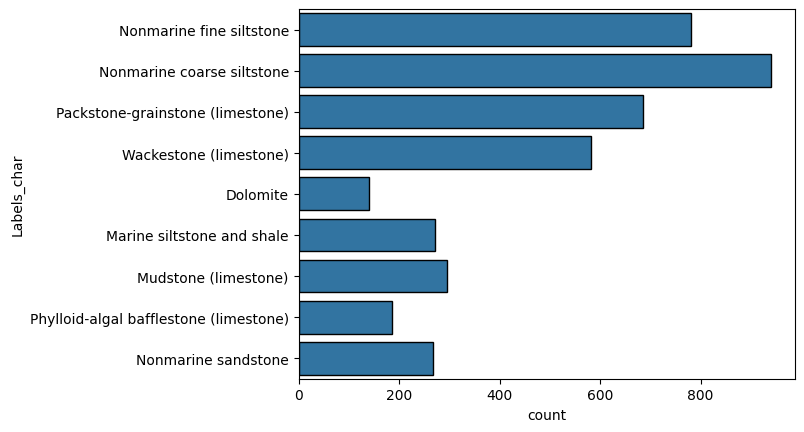

In [8]:
# Plotando o número de ocorrências de cada litologia
sns.countplot(data=df, y='Labels_char',edgecolor='black')

<Axes: xlabel='count', ylabel='Labels_char'>

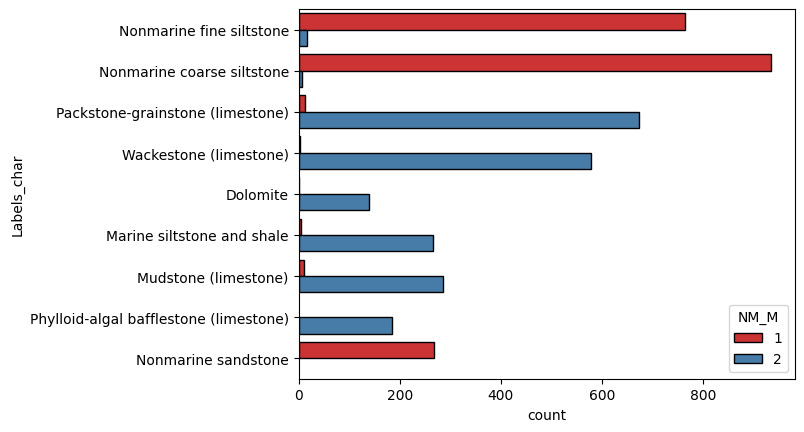

In [9]:
# Plotando a contagem de cada litologia e o ambiente de deposição

sns.countplot(data=df, y='Labels_char', hue='NM_M', palette='Set1',edgecolor='black')

In [10]:
# Corrigindo o rótulo numérico do ambiente de deposição

df.loc[df['Labels_char'].str.contains('Nonmarine', case=False, na=False), 'NM_M'] =1

df.loc[df['Labels_char'].str.contains('Marine', case=False, na=False), 'NM_M'] = 2

<Axes: xlabel='count', ylabel='Labels_char'>

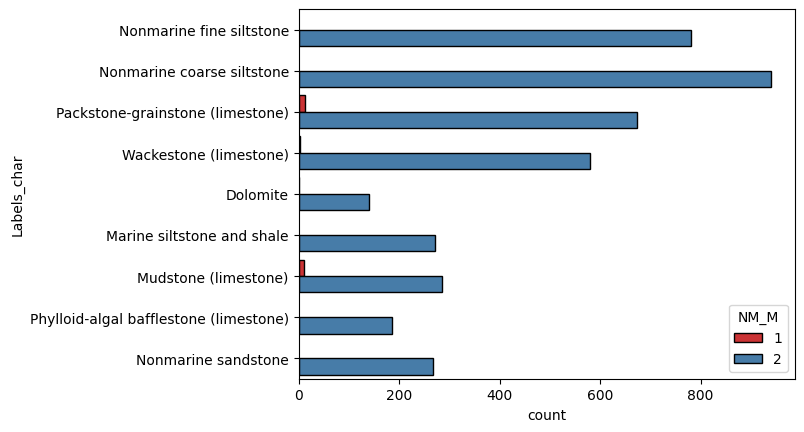

In [11]:
# Plotando a contagem de cada litologia e o ambiente de deposição para verificar se a correção foi feita corretamente

sns.countplot(data=df, y='Labels_char', hue='NM_M', palette='Set1',edgecolor='black')

#### Aumento de atributos (*data augmentation*)

Observe que a **porosidade neutrônica** e a **porosidade derivada da densidade** podem ser recuperadas a partir das variáveis `DeltaPHI` e `PHIND`.

As relações originais são dadas por:

$$
\Delta \phi = \phi_N - \phi_D
$$

$$
PHIND = \frac{\phi_N + \phi_D}{2}
$$

A partir dessas expressões, podemos isolar as duas porosidades:

$$
\phi_N = \frac{\Delta \phi + 2 \, PHIND}{2}
$$

$$
\phi_D = \frac{2 \, PHIND - \Delta \phi}{2}
$$

In [25]:
# Funções para calcular as curvas de porosidade efetiva e porosidade total a partir da curva de porosidade aparente (PHIND) e da curva de delta porosidade (DeltaPHI)

def phi_N(delta_phi,phi_nd):
    delta_phi = np.asarray(delta_phi); phi_nd = np.asarray(phi_nd)
    return (delta_phi+(2*phi_nd))/2

def phi_D(delta_phi,phi_nd):
    delta_phi = np.asarray(delta_phi); phi_nd = np.asarray(phi_nd)
    return (-delta_phi+(2*phi_nd))/2

In [26]:
#Calculando as porosidades densidade e neutrônica

df['PHID'] = phi_D(df.DeltaPHI,df.PHIND)
df['PHIN'] = phi_N(df.DeltaPHI,df.PHIND)

df.head()

,Facies,Formation,Well Name,Depth,GR,ILD_log10,DeltaPHI,PHIND,PE,NM_M,RELPOS,Labels_char,Formation_num,PHID,PHIN
0,3,A1 SH,SHRIMPLIN,2793.0,77.45,0.664,9.9,11.915,4.6,2,1.000,Nonmarine fine siltstone,1,6.965,16.865
1,3,A1 SH,SHRIMPLIN,2793.5,78.26,0.661,14.2,12.565,4.1,2,0.979,Nonmarine fine siltstone,1,5.465,19.665
2,3,A1 SH,SHRIMPLIN,2794.0,79.05,0.658,14.8,13.050,3.6,2,0.957,Nonmarine fine siltstone,1,5.650,20.450
3,3,A1 SH,SHRIMPLIN,2794.5,86.10,0.655,13.9,13.115,3.5,2,0.936,Nonmarine fine siltstone,1,6.165,20.065
4,3,A1 SH,SHRIMPLIN,2795.0,74.58,0.647,13.5,13.300,3.4,2,0.915,Nonmarine fine siltstone,1,6.550,20.050


In [27]:
dict(enumerate(df['Formation'].astype('category').cat.categories))

{0: 'A1 LM',
 1: 'A1 SH',
 2: 'B1 LM',
 3: 'B1 SH',
 4: 'B2 LM',
 5: 'B2 SH',
 6: 'B3 LM',
 7: 'B3 SH',
 8: 'B4 LM',
 9: 'B4 SH',
 10: 'B5 LM',
 11: 'B5 SH',
 12: 'C LM',
 13: 'C SH'}

In [28]:
# Criando uma coluna numérica para as formações (Formation)
df['Formation_num'] = df['Formation'].astype('category').cat.codes

df.head()

,Facies,Formation,Well Name,Depth,GR,ILD_log10,DeltaPHI,PHIND,PE,NM_M,RELPOS,Labels_char,Formation_num,PHID,PHIN
0,3,A1 SH,SHRIMPLIN,2793.0,77.45,0.664,9.9,11.915,4.6,2,1.000,Nonmarine fine siltstone,1,6.965,16.865
1,3,A1 SH,SHRIMPLIN,2793.5,78.26,0.661,14.2,12.565,4.1,2,0.979,Nonmarine fine siltstone,1,5.465,19.665
2,3,A1 SH,SHRIMPLIN,2794.0,79.05,0.658,14.8,13.050,3.6,2,0.957,Nonmarine fine siltstone,1,5.650,20.450
3,3,A1 SH,SHRIMPLIN,2794.5,86.10,0.655,13.9,13.115,3.5,2,0.936,Nonmarine fine siltstone,1,6.165,20.065
4,3,A1 SH,SHRIMPLIN,2795.0,74.58,0.647,13.5,13.300,3.4,2,0.915,Nonmarine fine siltstone,1,6.550,20.050


In [29]:
# Salvando um dicionário para mapear os códigos numéricos de volta para os nomes das formações
formation_mapping = dict(enumerate(df['Formation'].astype('category').cat.categories))
formation_mapping

{0: 'A1 LM',
 1: 'A1 SH',
 2: 'B1 LM',
 3: 'B1 SH',
 4: 'B2 LM',
 5: 'B2 SH',
 6: 'B3 LM',
 7: 'B3 SH',
 8: 'B4 LM',
 9: 'B4 SH',
 10: 'B5 LM',
 11: 'B5 SH',
 12: 'C LM',
 13: 'C SH'}

In [30]:
# Realizando o mesmo procedimento acima com o sklearn para verificar se o resultado é o mesmo

label_encoder = LabelEncoder()
df['Formation_num_sklearn'] = label_encoder.fit_transform(df['Formation'])
df.head()

,Facies,Formation,Well Name,Depth,GR,ILD_log10,DeltaPHI,PHIND,PE,NM_M,RELPOS,Labels_char,Formation_num,PHID,PHIN,Formation_num_sklearn
0,3,A1 SH,SHRIMPLIN,2793.0,77.45,0.664,9.9,11.915,4.6,2,1.000,Nonmarine fine siltstone,1,6.965,16.865,1
1,3,A1 SH,SHRIMPLIN,2793.5,78.26,0.661,14.2,12.565,4.1,2,0.979,Nonmarine fine siltstone,1,5.465,19.665,1
2,3,A1 SH,SHRIMPLIN,2794.0,79.05,0.658,14.8,13.050,3.6,2,0.957,Nonmarine fine siltstone,1,5.650,20.450,1
3,3,A1 SH,SHRIMPLIN,2794.5,86.10,0.655,13.9,13.115,3.5,2,0.936,Nonmarine fine siltstone,1,6.165,20.065,1
4,3,A1 SH,SHRIMPLIN,2795.0,74.58,0.647,13.5,13.300,3.4,2,0.915,Nonmarine fine siltstone,1,6.550,20.050,1


In [31]:
# Deletando coluna para evitar repetição de informações
del(df['Formation_num_sklearn'])

In [32]:
df.head()

,Facies,Formation,Well Name,Depth,GR,ILD_log10,DeltaPHI,PHIND,PE,NM_M,RELPOS,Labels_char,Formation_num,PHID,PHIN
0,3,A1 SH,SHRIMPLIN,2793.0,77.45,0.664,9.9,11.915,4.6,2,1.000,Nonmarine fine siltstone,1,6.965,16.865
1,3,A1 SH,SHRIMPLIN,2793.5,78.26,0.661,14.2,12.565,4.1,2,0.979,Nonmarine fine siltstone,1,5.465,19.665
2,3,A1 SH,SHRIMPLIN,2794.0,79.05,0.658,14.8,13.050,3.6,2,0.957,Nonmarine fine siltstone,1,5.650,20.450
3,3,A1 SH,SHRIMPLIN,2794.5,86.10,0.655,13.9,13.115,3.5,2,0.936,Nonmarine fine siltstone,1,6.165,20.065
4,3,A1 SH,SHRIMPLIN,2795.0,74.58,0.647,13.5,13.300,3.4,2,0.915,Nonmarine fine siltstone,1,6.550,20.050


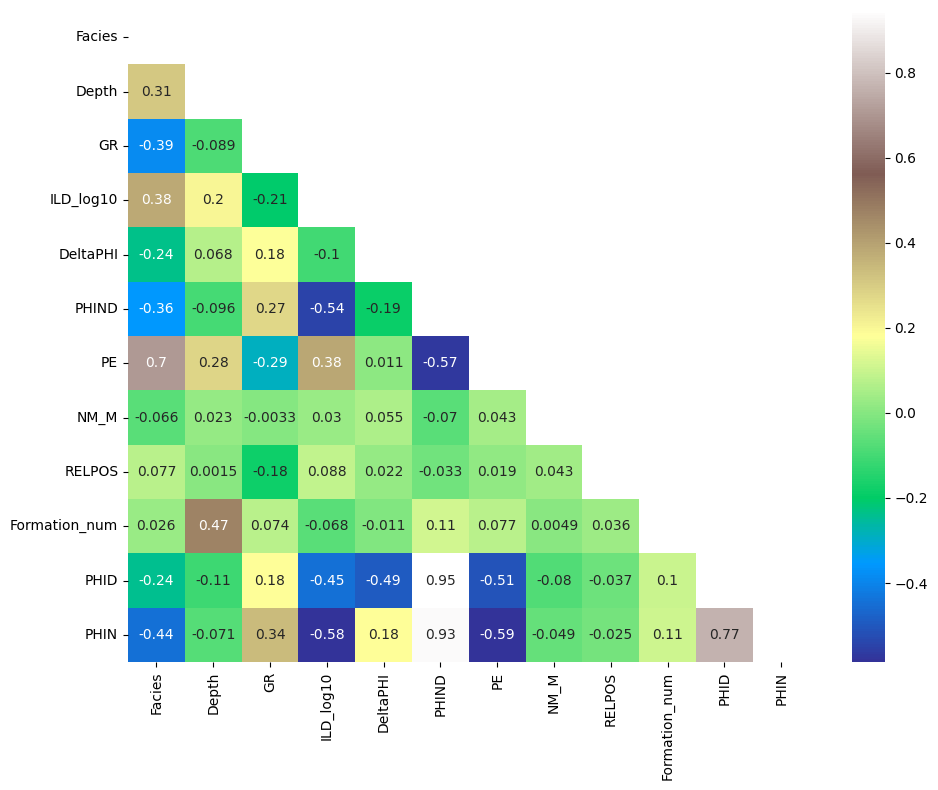

In [33]:
# Plotando a matriz de correlação entre as variáveis numéricas

corr = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='terrain',
    ax=ax
)

fig.tight_layout()

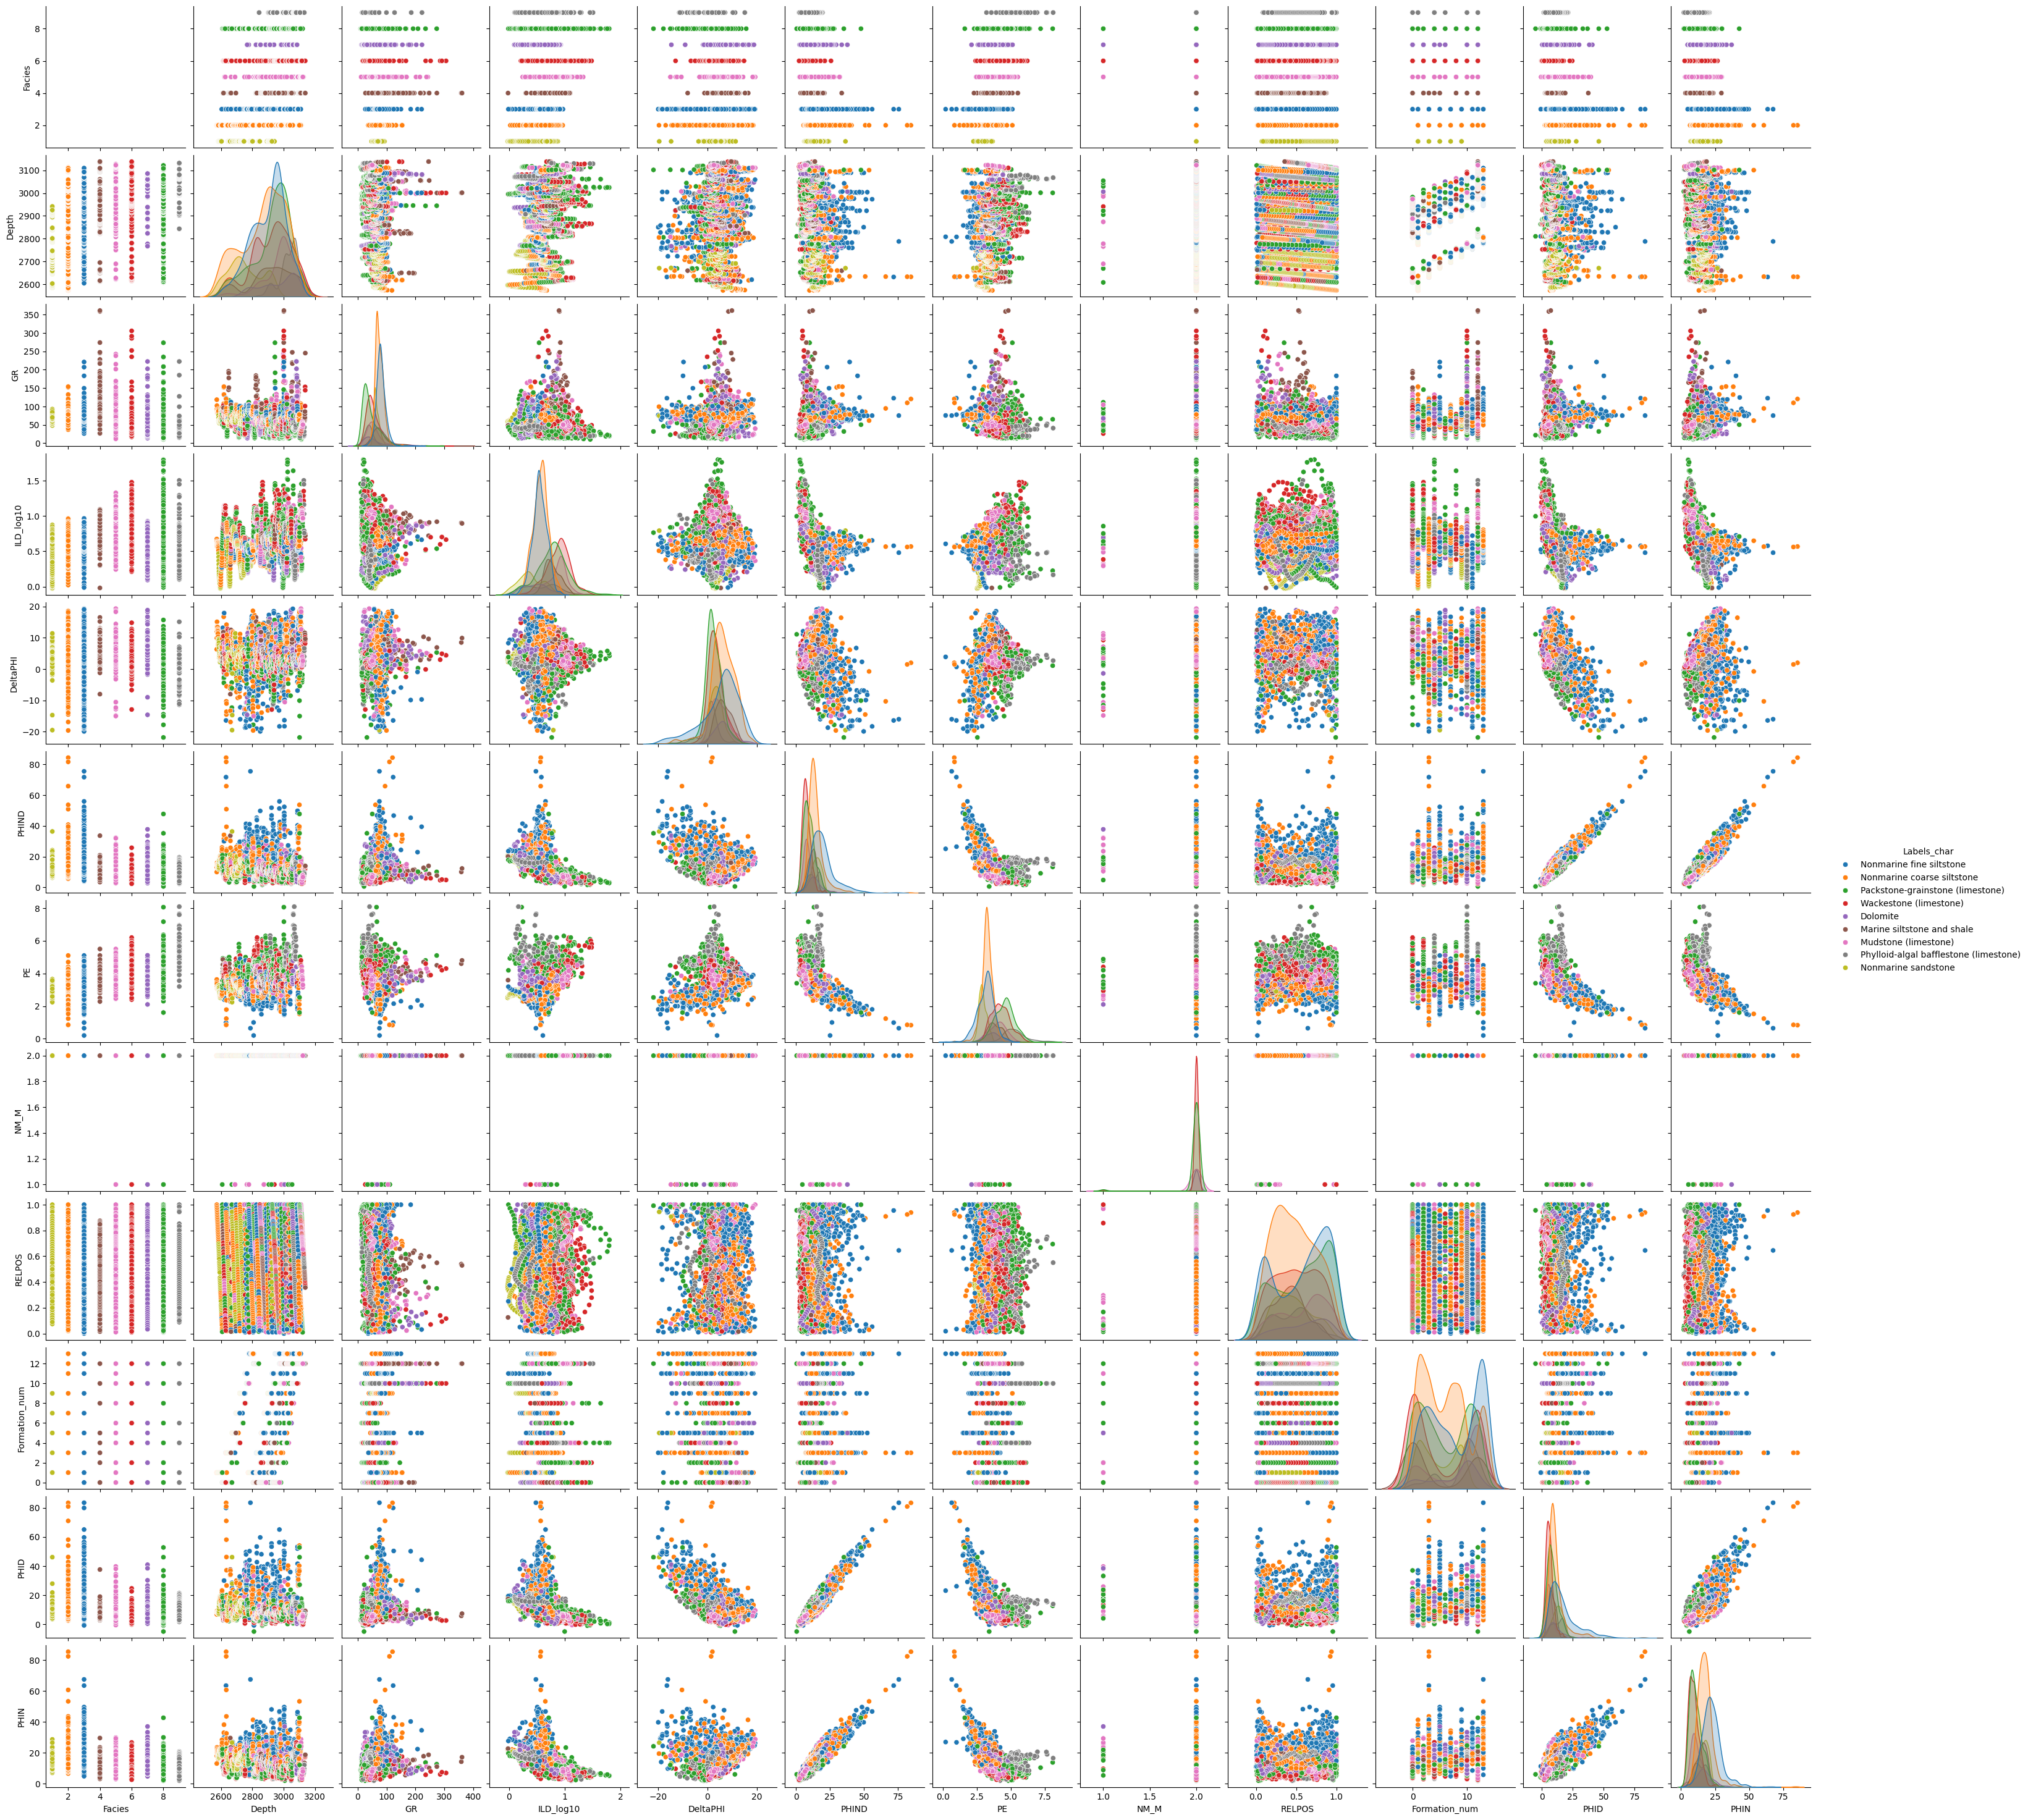

In [34]:
# Plotando o pairplot das variáveis numéricas para verificar a relação entre elas

numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist() + ['Labels_char']

sns.pairplot(df[numeric_columns],hue='Labels_char')

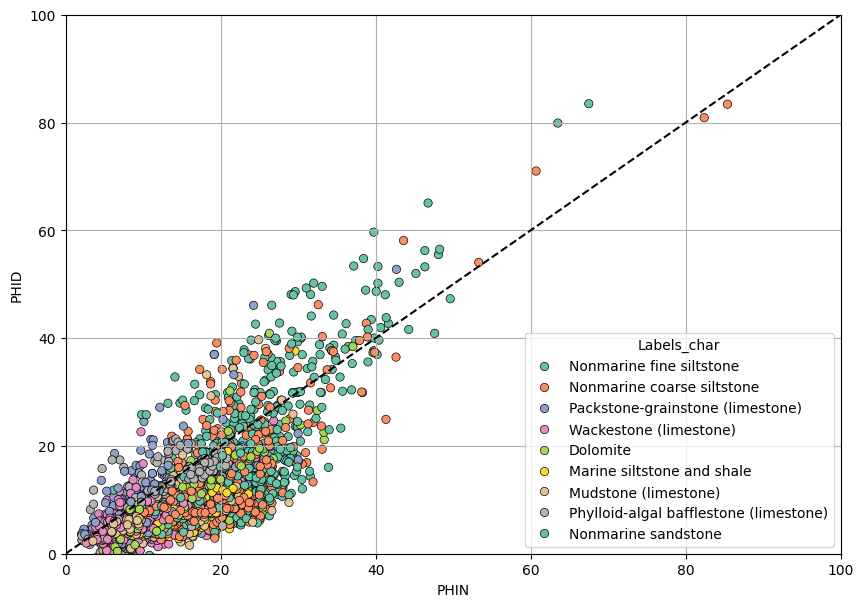

In [36]:
# Plotando PHIN vs PHID com o tipo de litologia como cor

fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(data=df, x='PHIN', y='PHID', hue='Labels_char', palette='Set2', edgecolor='black')

#Plotando bisetriz para comparação entre PHIN e PHID

x = np.linspace(0, 100, 100)
ax.plot(x, x, color='black', linestyle='--')

ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

ax.grid(True)


#### Vamos realizar nossa primeira regressão linear para prever PE

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [38]:
df.select_dtypes(include=[np.number]).columns.tolist()

['Facies',
 'Depth',
 'GR',
 'ILD_log10',
 'DeltaPHI',
 'PHIND',
 'PE',
 'NM_M',
 'RELPOS',
 'Formation_num',
 'PHID',
 'PHIN']

In [39]:
cols = df.select_dtypes(include=[np.number]).columns.tolist()
cols.remove('Depth')
cols.remove('PE')

cols

['Facies',
 'GR',
 'ILD_log10',
 'DeltaPHI',
 'PHIND',
 'NM_M',
 'RELPOS',
 'Formation_num',
 'PHID',
 'PHIN']

In [40]:
# Separando os atributos (X) da variável alvo (y)
X = df[df['PE'].notna()][cols]
y = df[df['PE'].notna()]['PE']

In [41]:
Scaler = StandardScaler()
X_scaled = Scaler.fit_transform(X)

In [75]:
# Separando os dados em conjuntos de treino e teste

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [76]:
# Realizando o ajuste com todas as variáveis numéricas
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [77]:
# Testando o modelo no conjunto de teste
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.4f}')
print(f'R^2 Score: {r2:.4f}')

Mean Squared Error: 0.3348
R^2 Score: 0.6126


In [78]:
# Vamos otimizar o modelo testando todas as combinações possíveis de variáveis numéricas para encontrar a melhor combinação que maximize o R^2 Score e minimize o Mean Squared Error.

from sklearn.feature_selection import RFECV

selector = RFECV(estimator=LinearRegression(), step=1, cv=5, scoring='neg_root_mean_squared_error')

selector.fit(X_train, y_train)

,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,LinearRegression()
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",5
,"scoring scoring: str or callable, default=NoneScoring method to evaluate the :class:`RFE` selectors' performance. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",'neg_root_mean_squared_error'
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"n_jobs n_jobs: int or None, default=NoneNumber of cores to run in parallel while fitting across folds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance.For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [79]:
# Realizando a predição na porção de dados onde PE era ausente

X_pred = df[cols]
X_pred_scaled_2 = Scaler.transform(X_pred)
y_pred_missing = model.predict(X_pred_scaled_2)

df['PE_reg_lin'] = y_pred_missing

# X_pred = df[df['PE'].isna()][cols]
# X_pred_scaled = Scaler.transform(X_pred)
# y_pred_missing = model.predict(X_pred_scaled)
#df.loc[df['PE'].isna(), 'PE'] = y_pred_missing



In [80]:
df['PE_reg_lin'] = model.predict(Scaler.transform(df[cols]))

In [81]:
df['Well Name'].unique().tolist()

['SHRIMPLIN',
 'ALEXANDER D',
 'SHANKLE',
 'LUKE G U',
 'KIMZEY A',
 'CROSS H CATTLE',
 'NOLAN',
 'Recruit F9',
 'NEWBY',
 'CHURCHMAN BIBLE']

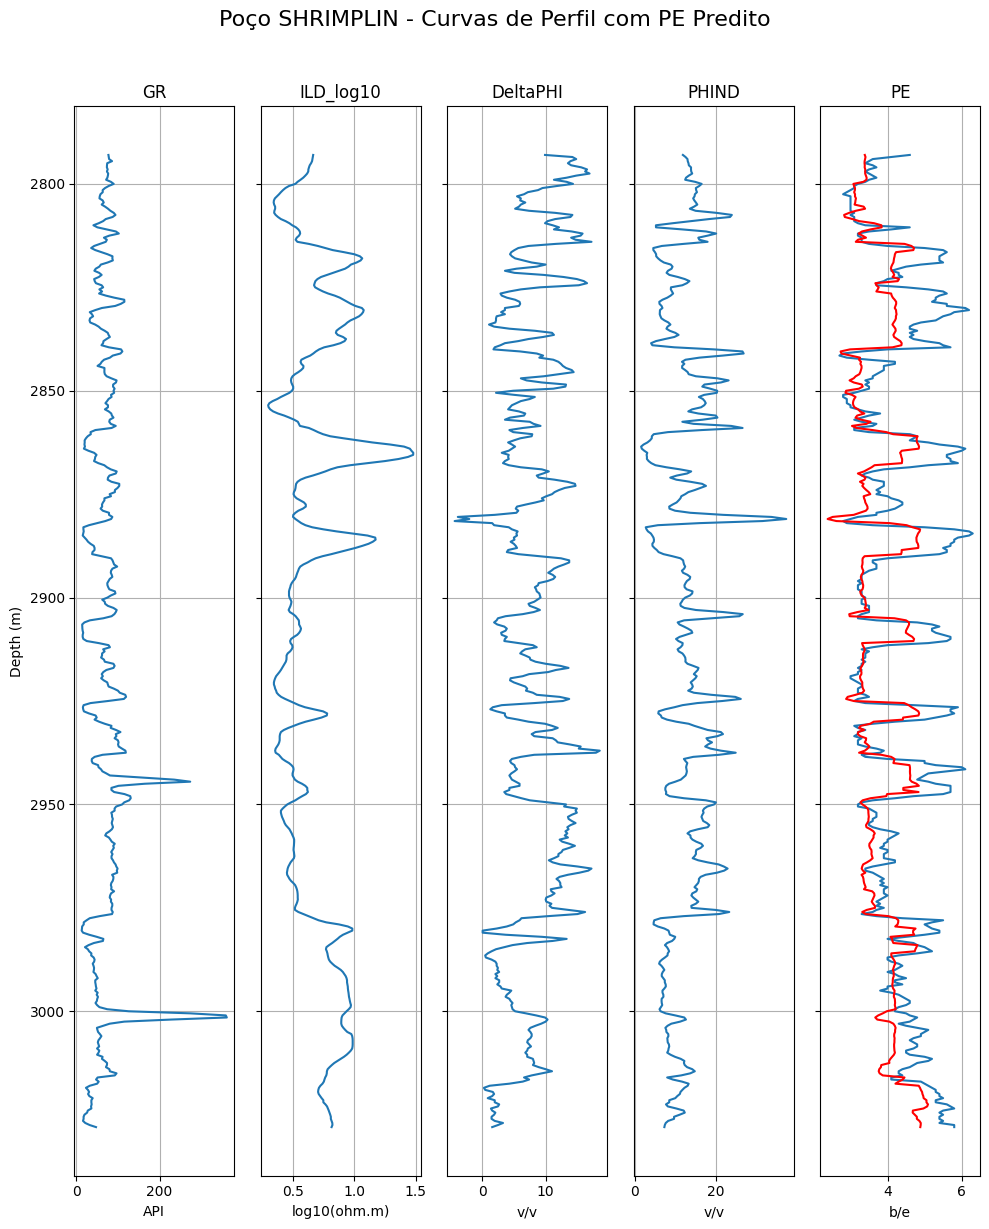

In [82]:
cols_plot = ['GR', 'ILD_log10', 'DeltaPHI', 'PHIND', 'PE']

well_name = 'SHRIMPLIN'

fig,axes = plot_well_logs(
    df=df,
    well_name=well_name,
    cols=cols_plot,
    depth_unit='m',
    x_units=units,
    title='Poço SHRIMPLIN - Curvas de Perfil com PE Predito'
)

axes[-1].plot(df[df['Well Name'] == well_name]['PE_reg_lin'], df[df['Well Name'] == well_name]['Depth'], color='red', label='PE Predito')

In [83]:
from sklearn.decomposition import PCA

In [84]:
pca = PCA()
pca.fit(X_train)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

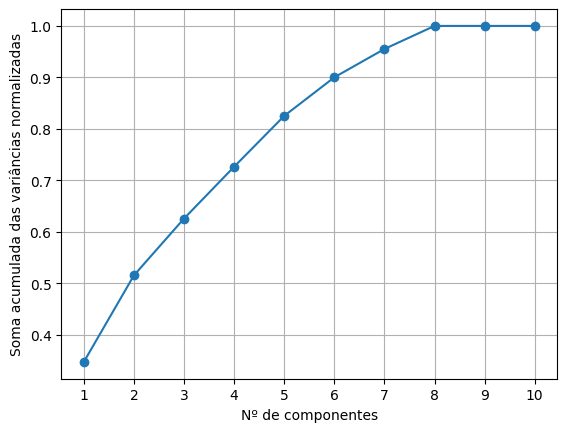

In [85]:
fig,axes = plt.subplots()

axes.plot(np.arange(1,len(pca.explained_variance_)+1),np.cumsum(pca.explained_variance_ratio_),marker="o")
axes.set_xticks(np.arange(1,len(pca.explained_variance_)+1))

axes.set_xlabel('Nº de componentes')

axes.set_ylabel('Soma acumulada das variâncias normalizadas')

axes.grid()


In [86]:
pca.transform(X_train).shape

(2585, 10)

In [87]:
lr_pca = LinearRegression()

X_train_PCA = pca.transform(X_train)[:,:-3]
X_test_PCA = pca.transform(X_test)[:,:-3]

lr_pca.fit(X_train_PCA,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [89]:
# Testando o modelo no conjunto de teste
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('Teste sem PCA')
print(f'Mean Squared Error: {mse:.4f}')
print(f'R^2 Score: {r2:.4f}')
print('================================')


y_pred_PCA = lr_pca.predict(X_test_PCA)
mse = mean_squared_error(y_test, y_pred_PCA)
r2 = r2_score(y_test, y_pred_PCA)

print('Teste com PCA')
print(f'Mean Squared Error: {mse:.4f}')
print(f'R^2 Score: {r2:.4f}')
print('================================')

Teste sem PCA
Mean Squared Error: 0.3348
R^2 Score: 0.6126
Teste com PCA
Mean Squared Error: 0.3384
R^2 Score: 0.6084


In [90]:
df['PE_reg_lin_PCA'] = lr_pca.predict(pca.transform(Scaler.transform(df[cols]))[:,:-3])

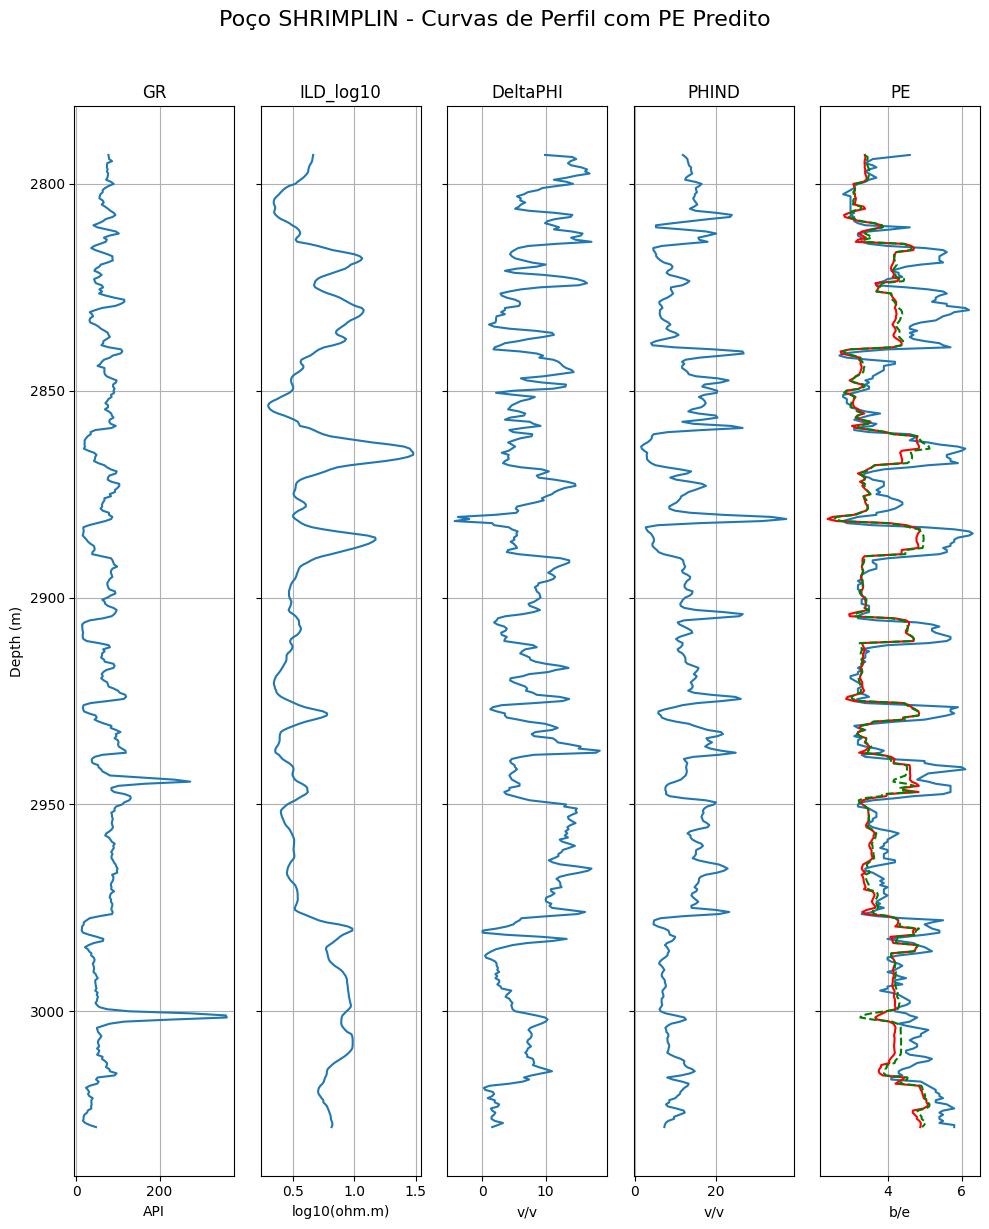

In [91]:
cols_plot = ['GR', 'ILD_log10', 'DeltaPHI', 'PHIND', 'PE']

well_name = 'SHRIMPLIN'

fig,axes = plot_well_logs(
    df=df,
    well_name=well_name,
    cols=cols_plot,
    depth_unit='m',
    x_units=units,
    title='Poço SHRIMPLIN - Curvas de Perfil com PE Predito'
)

axes[-1].plot(df[df['Well Name'] == well_name]['PE_reg_lin'], df[df['Well Name'] == well_name]['Depth'], color='red', label='PE Predito')

axes[-1].plot(df[df['Well Name'] == well_name]['PE_reg_lin_PCA'], df[df['Well Name'] == well_name]['Depth'], color='green', label='PE Predito',ls='--')

#### Exercício 

##### Faça a regressão utilizando o modelo KNN e compare os resultados com o modelo de regressão linear. Qual modelo apresentou melhor desempenho? Justifique sua resposta.

In [92]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

In [93]:
knn = KNeighborsRegressor()

params = {
    'n_neighbors': np.arange(1,51,2),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(estimator=knn, param_grid=params, cv=5, scoring='neg_root_mean_squared_error')
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': array([ 1, 3..., 45, 47, 49]), 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fol

In [94]:
grid_search.best_params_

{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}

In [95]:
# Elecando os melhores resultados do GridSearchCV para o modelo KNN

pd.DataFrame(grid_search.cv_results_).sort_values(by='mean_test_score', ascending=False).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_metric,param_n_neighbors,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
53,0.001598,0.000488,0.008308,0.000812,manhattan,3,distance,"{'metric': 'manhattan', 'n_neighbors': 3, 'wei...",-0.370257,-0.348797,-0.375916,-0.379730,-0.419211,-0.378782,0.022871,1
55,0.001799,0.000400,0.009154,0.000546,manhattan,5,distance,"{'metric': 'manhattan', 'n_neighbors': 5, 'wei...",-0.370972,-0.361635,-0.364786,-0.395490,-0.401520,-0.378881,0.016413,2
57,0.001507,0.000446,0.009944,0.000495,manhattan,7,distance,"{'metric': 'manhattan', 'n_neighbors': 7, 'wei...",-0.376810,-0.367668,-0.369383,-0.398231,-0.400332,-0.382485,0.014070,3
3,0.002147,0.000808,0.007677,0.001474,euclidean,3,distance,"{'metric': 'euclidean', 'n_neighbors': 3, 'wei...",-0.367493,-0.352234,-0.379223,-0.411408,-0.433616,-0.388795,0.029673,4
5,0.002002,0.000003,0.007230,0.000155,euclidean,5,distance,"{'metric': 'euclidean', 'n_neighbors': 5, 'wei...",-0.370940,-0.370855,-0.377903,-0.406935,-0.418282,-0.388983,0.019787,5


In [96]:
# Comparando com o modelo de regressão linear

grid_search.best_estimator_.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'manhattan'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [97]:
print(f'Erro médio quadrático da regressão linear: {mean_squared_error(y_test, model.predict(X_test)):.4f}')
print(f'Erro médio quadrático do KNN: {mean_squared_error(y_test, grid_search.best_estimator_.predict(X_test)):.4f}')

Erro médio quadrático da regressão linear: 0.3348
Erro médio quadrático do KNN: 0.1242


In [98]:
print(f'R^2 Score da regressão linear: {r2_score(y_test, model.predict(X_test)):.4f}')
print(f'R^2 Score do KNN: {r2_score(y_test, grid_search.best_estimator_.predict(X_test)):.4f}')

R^2 Score da regressão linear: 0.6126
R^2 Score do KNN: 0.8563


In [99]:
#Adicionando ao o resultado do PE ao DataFrame
df['KNN_PE'] = grid_search.best_estimator_.predict(Scaler.transform(df[cols]))

In [100]:
df

,Facies,Formation,Well Name,Depth,GR,ILD_log10,DeltaPHI,PHIND,PE,NM_M,RELPOS,Labels_char,PHID,PHIN,Formation_num,PE_reg_lin,KNN_PE
0,3,A1 SH,SHRIMPLIN,2793.0,77.450,0.664,9.900,11.915,4.600,2,1.000,Nonmarine fine siltstone,6.9650,16.8650,1,3.385422,3.400
1,3,A1 SH,SHRIMPLIN,2793.5,78.260,0.661,14.200,12.565,4.100,2,0.979,Nonmarine fine siltstone,5.4650,19.6650,1,3.405093,4.100
2,3,A1 SH,SHRIMPLIN,2794.0,79.050,0.658,14.800,13.050,3.600,2,0.957,Nonmarine fine siltstone,5.6500,20.4500,1,3.393572,3.600
3,3,A1 SH,SHRIMPLIN,2794.5,86.100,0.655,13.900,13.115,3.500,2,0.936,Nonmarine fine siltstone,6.1650,20.0650,1,3.381227,3.500
4,3,A1 SH,SHRIMPLIN,2795.0,74.580,0.647,13.500,13.300,3.400,2,0.915,Nonmarine fine siltstone,6.5500,20.0500,1,3.378932,3.400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4144,5,C LM,CHURCHMAN BIBLE,3120.5,46.719,0.947,1.828,7.254,3.617,2,0.685,Mudstone (limestone),6.3400,8.1680,12,4.139919,3.617
4145,5,C LM,CHURCHMAN BIBLE,3121.0,44.563,0.953,2.241,8.013,3.344,2,0.677,Mudstone (limestone),6.8925,9.1335,12,4.112950,3.344
4146,5,C LM,CHURCHMAN BIBLE,3121.5,49.719,0.964,2.925,8.013,3.190,2,0.669,Mudstone (limestone),6.5505,9.4755,12,4.116963,3.190
4147,5,C LM,CHURCHMAN BIBLE,3122.0,51.469,0.965,3.083,7.708,3.152,2,0.661,Mudstone (limestone),6.1665,9.2495,12,4.131757,3.152


In [101]:
# Analisando os resultados obtidos

import ipywidgets as widgets
from ipywidgets import interact

wells = sorted(df['Well Name'].unique())

cols_plot = ['GR', 'ILD_log10', 'DeltaPHI', 'PHIND', 'PE','PE_reg_lin','KNN_PE']

x_units = {
    'GR': 'API',
    'ILD_log10': 'log10(ohm.m)',
    'DeltaPHI': 'v/v',
    'PHIND': 'v/v',
    'PE': 'b/e',
    'PE_reg_lin': 'b/e',
    'KNN_PE': 'b/e'
}

def interactive_plot(well_name):
    plt.close('all')
    plot_well_logs(
        df=df,
        well_name=well_name,
        cols=cols_plot,
        depth_unit='m',
        x_units=x_units
    )
    plt.show()

interact(interactive_plot, well_name=wells)

interactive(children=(Dropdown(description='well_name', options=('ALEXANDER D', 'CHURCHMAN BIBLE', 'CROSS H CA…

<function __main__.interactive_plot(well_name)>

In [102]:
# Substituindo apenas os valores ausentes de PE pelos valores preditos pelo modelo do KNN
df['PE_Rec'] = df['PE'] # Criando uma nova coluna para armazenar os valores de PE corrigidos
df.loc[df['PE'].isnull(), 'PE_Rec'] = df.loc[df['PE'].isnull(), 'KNN_PE']

In [ ]:
wells = sorted(df['Well Name'].unique())

cols_plot = ['GR', 'ILD_log10', 'DeltaPHI', 'PHIND', 'PE','PE_Rec']

x_units = {
    'GR': 'API',
    'ILD_log10': 'log10(ohm.m)',
    'DeltaPHI': 'v/v',
    'PHIND': 'v/v',
    'PE': 'b/e',
    'PE_reg_lin': 'b/e',
    'KNN_PE': 'b/e'
}

def interactive_plot(well_name):
    plt.close('all')
    plot_well_logs(
        df=df,
        well_name=well_name,
        cols=cols_plot,
        depth_unit='m',
        x_units=x_units
    )
    plt.show()

interact(interactive_plot, well_name=wells)

interactive(children=(Dropdown(description='well_name', options=('ALEXANDER D', 'CHURCHMAN BIBLE', 'CROSS H CA…

<function __main__.interactive_plot(well_name)>

In [104]:
# Salvando o resultado final em um arquivo .csv para utiliza-lo na tarefa de classificação

df.to_csv('..\\..\\data\\csv\\facies_vectors_pre_proc.csv', index=False)